<a href="https://colab.research.google.com/github/Anzonfire/Machine-Learning/blob/main/expno%203/3_scenario_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Degree: 2
MSE: 13.94115894036442
RMSE: 3.733786140148418
R2: 0.7407089260880413
Degree: 3
MSE: 13.987543053794557
RMSE: 3.7399923868631815
R2: 0.7398462297630657
Degree: 4
MSE: 14.443392221902474
RMSE: 3.800446318776582
R2: 0.7313679087822789
Ridge R2: 0.7409905386487489


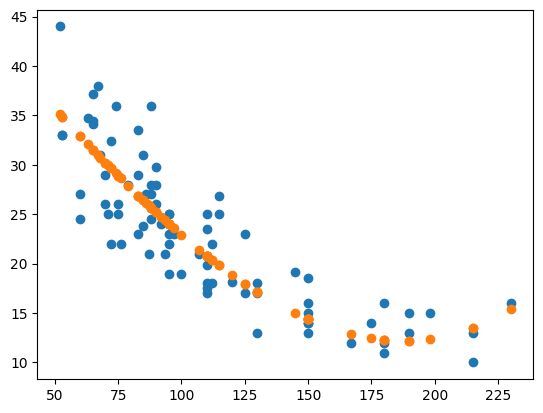

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

df_auto = pd.read_csv("auto-mpg.csv")

df_auto.replace("?", np.nan, inplace=True)
df_auto["horsepower"] = pd.to_numeric(df_auto["horsepower"])
df_auto.fillna(df_auto.median(numeric_only=True), inplace=True)

X = df_auto[["horsepower"]]
y = df_auto["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = [2, 3, 4]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Degree:", d)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

ridge_pred = ridge.predict(X_test_poly)

print("Ridge R2:", r2_score(y_test, ridge_pred))

plt.scatter(X_test, y_test)
plt.scatter(X_test, ridge_pred)
plt.show()